# Лабораторная работа №2
## «Виртуальный датчик для контроля процесса обжига в печи»

Надо построить модель (soft sensor), которая прогнозирует концентрацию выходного продукта в реальном времени на основе минутной телеметрии, без ожидания лабораторного анализа.

**Данные:**
- `data_train.csv` — минутные измерения 16 показателей телеметрии за ~7 месяцев
- `target_train.csv` — нерегулярные лабораторные замеры с задержкой 10–15 мин
- `data_test_small.csv`, `target_test_small.csv` — аналогичные тестовые данные

In [8]:
# Установка зависимостей (раскомментируйте, чтобы do.)
# !pip install pandas==2.1.4 numpy==1.26.4 matplotlib==3.8.3 seaborn==0.13.2 \
#             scipy==1.12.0 statsmodels==0.14.1 lightgbm==4.3.0 \
#             xgboost==2.0.3 scikit-learn==1.4.2 shap==0.45.0

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

---
## 2.1 Разведочный анализ данных (EDA)

In [10]:
# ------------------------------------------------------------
# 1.1 Загрузка данных
# ------------------------------------------------------------

data_train = pd.read_csv('data_train.csv', parse_dates=['datetime'], index_col='datetime')

target_train = pd.read_csv('target_train.csv', parse_dates=['Дата'], index_col='Дата')
target_train.index.name = 'datetime'
target_train.columns = ['target']

data_test = pd.read_csv('data_test_small.csv', parse_dates=['datetime'], index_col='datetime')
target_test = pd.read_csv('target_test_small.csv', parse_dates=['Дата'], index_col='Дата')
target_test.index.name = 'datetime'
target_test.columns = ['target']

print('=== Телеметрия (train) ===')
print(f'Период: {data_train.index.min()} → {data_train.index.max()}')
print(f'Форма: {data_train.shape}')
print(f'Пропуски:\n{data_train.isnull().sum()}')
print('\n=== Целевая переменная (train) ===')
print(f'Период: {target_train.index.min()} → {target_train.index.max()}')
print(f'Форма: {target_train.shape}')
print(f'Пропуски: {target_train.isnull().sum().values[0]}')

=== Телеметрия (train) ===
Период: 2019-03-01 00:01:00 → 2019-10-07 19:58:00
Форма: (319546, 16)
Пропуски:
telemetry_0         17
telemetry_1         16
telemetry_2         16
telemetry_3         16
telemetry_4        133
telemetry_5         17
telemetry_6         16
telemetry_7         16
telemetry_8         16
telemetry_9         16
telemetry_10        16
telemetry_11        16
telemetry_12    317448
telemetry_13    317448
telemetry_14    317448
telemetry_15    317448
dtype: int64

=== Целевая переменная (train) ===
Период: 2019-03-13 17:00:00 → 2019-10-07 21:00:00
Форма: (1773, 1)
Пропуски: 0


**Наблюдение по пропускам:** telemetry_0–11 имеют единичные пропуски (<0.05%) — штатная телеметрия. Telemetry_12–15 заполнены лишь на ~0.6% (появились только в конце периода) — исключаем из обучения.

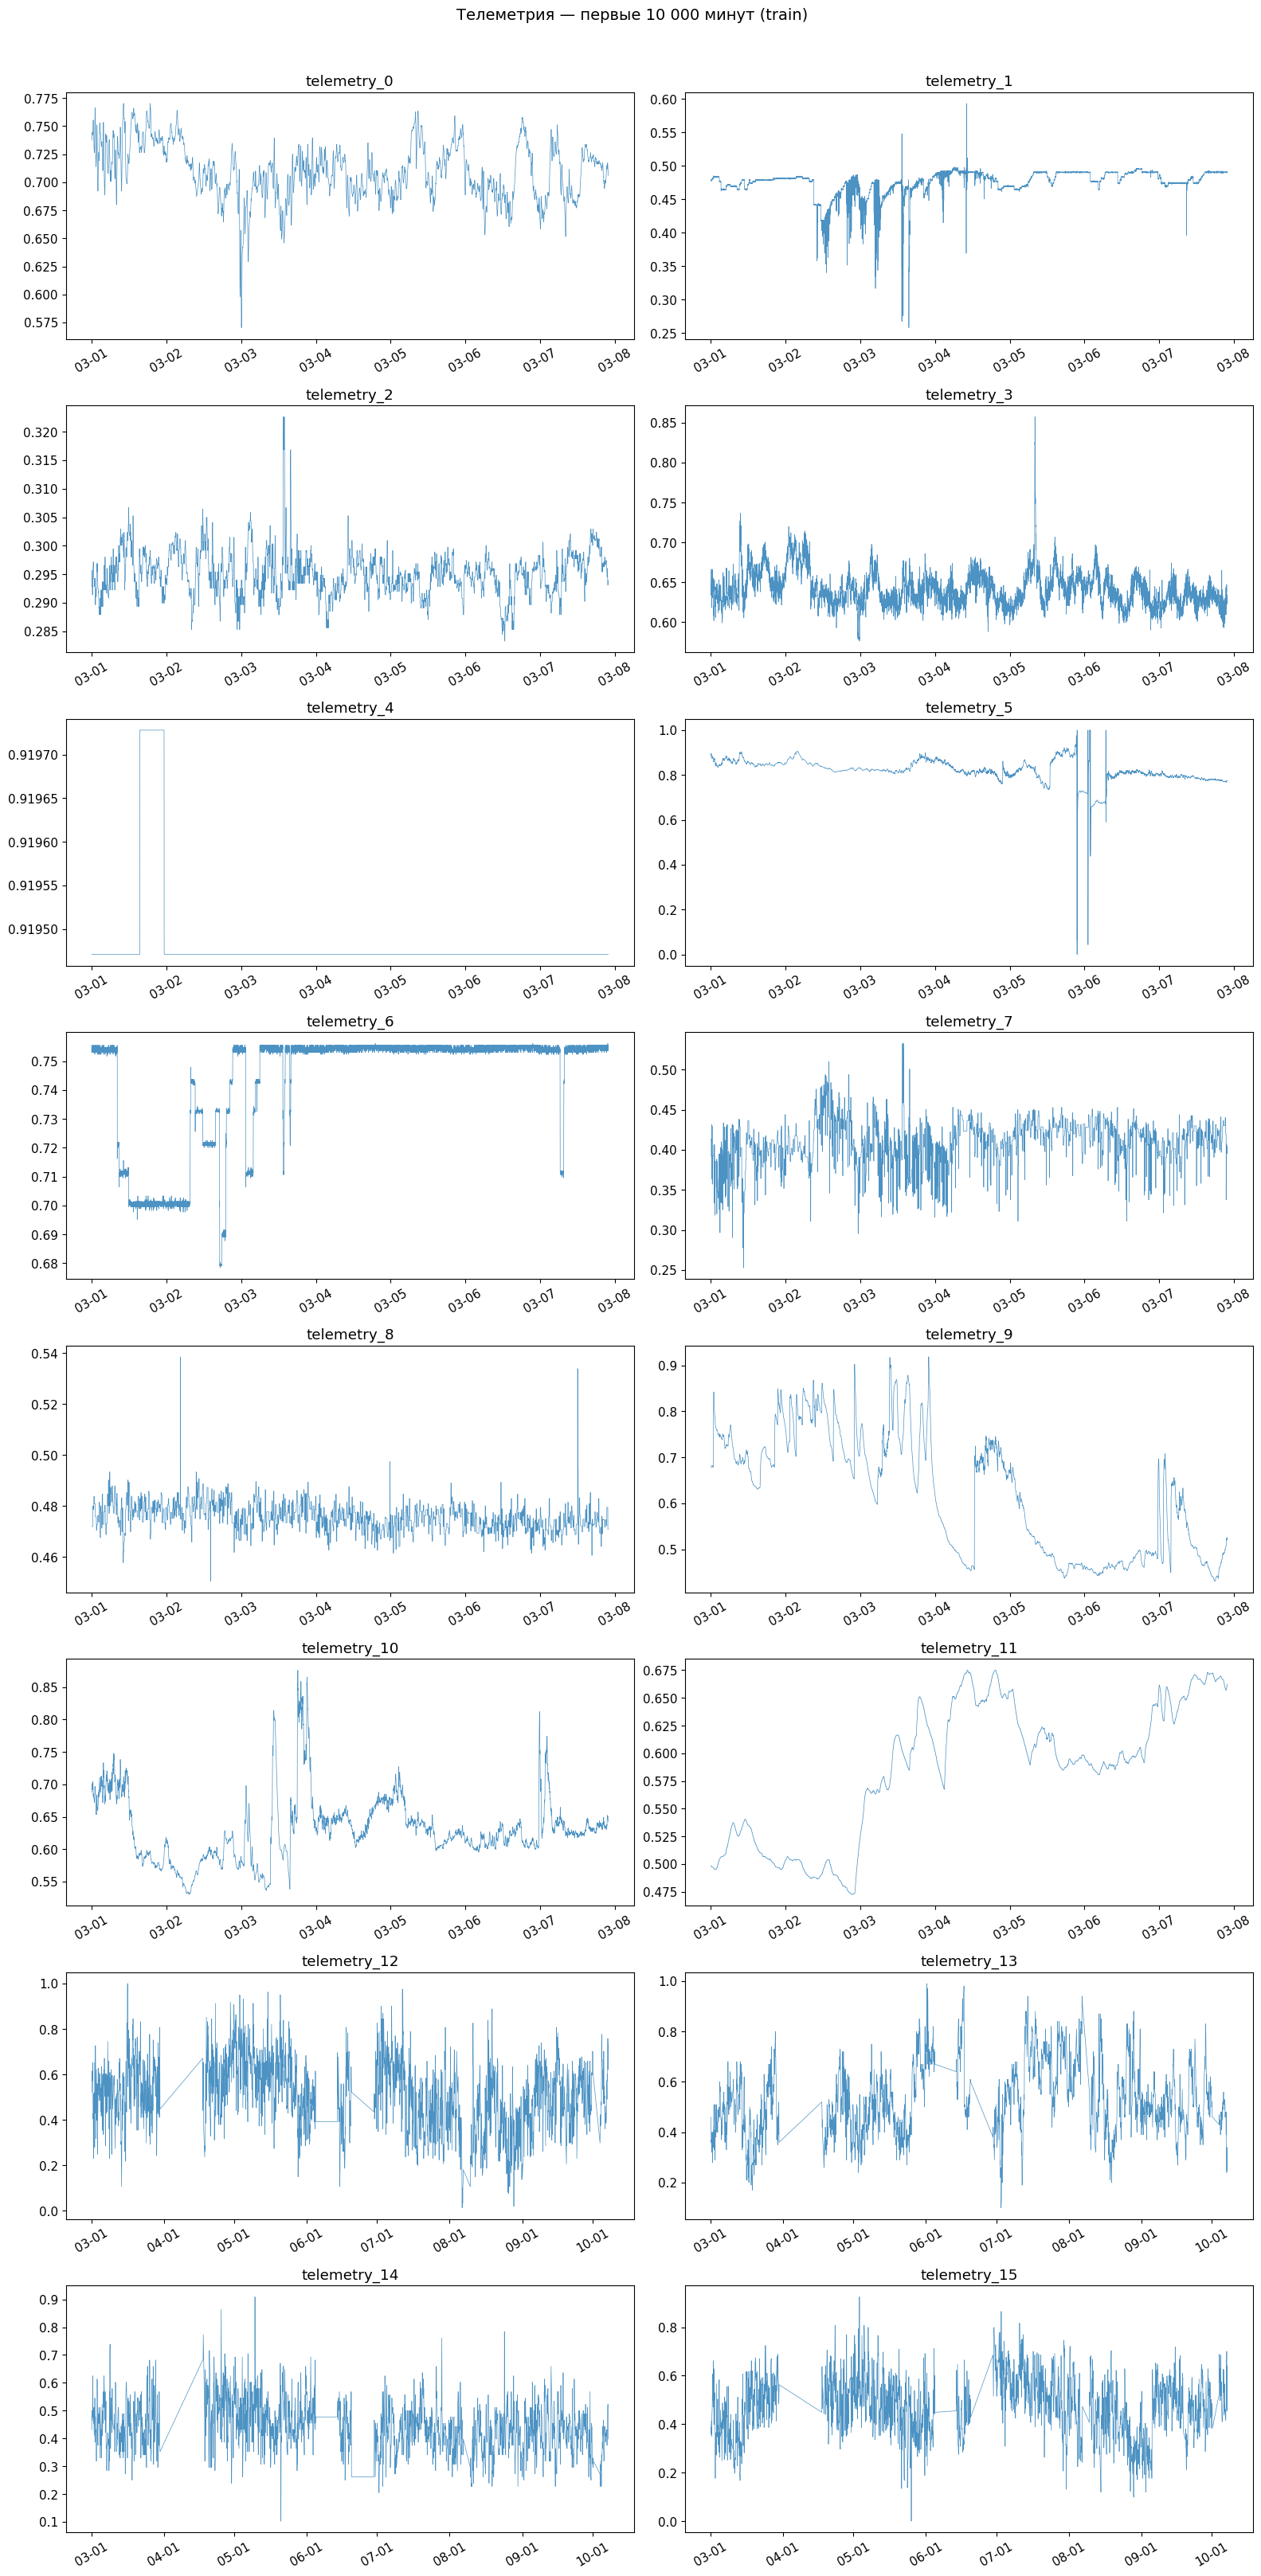

In [11]:
# ------------------------------------------------------------
# 1.2 Визуализация всех признаков телеметрии
# ------------------------------------------------------------

fig, axes = plt.subplots(8, 2, figsize=(16, 32))
axes = axes.flatten()

for i, col in enumerate(data_train.columns):
    ax = axes[i]
    sample = data_train[col].dropna().iloc[:10_000]
    ax.plot(sample.index, sample.values, linewidth=0.5, alpha=0.8)
    ax.set_title(col)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Телеметрия — первые 10 000 минут (train)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

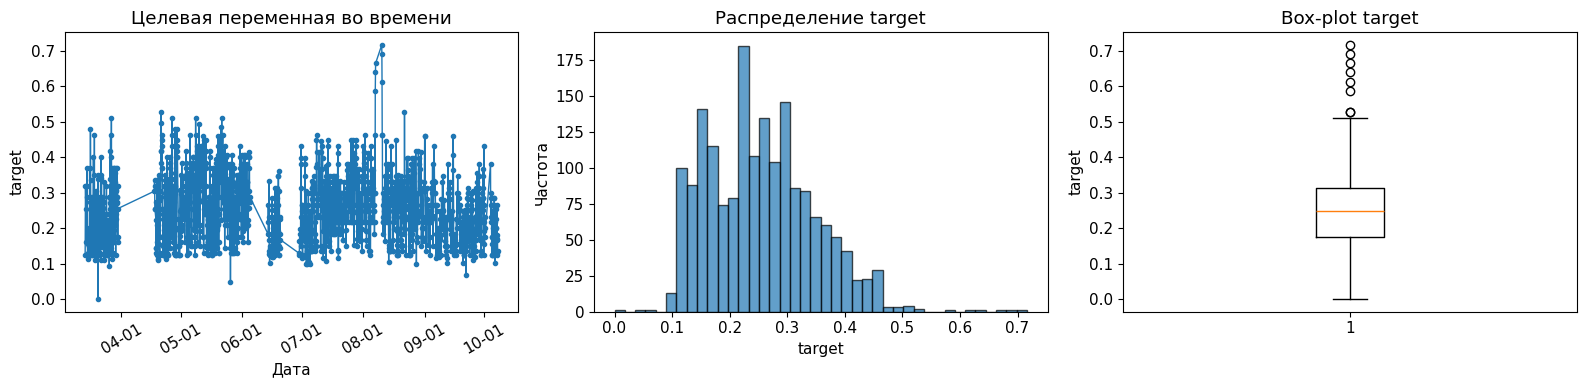

=== Статистика целевой переменной ===
count    1773.0000
mean        0.2543
std         0.0922
min         0.0000
25%         0.1753
50%         0.2474
75%         0.3144
max         0.7165
Name: target, dtype: float64

Медианный интервал между замерами: 0 days 02:00:00
Мин. интервал: 0 days 01:00:00
Макс. интервал: 18 days 08:30:00


In [12]:
# ------------------------------------------------------------
# 1.3 Анализ целевой переменной
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(target_train.index, target_train['target'], 'o-', markersize=3, linewidth=1)
axes[0].set_title('Целевая переменная во времени')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('target')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[0].tick_params(axis='x', rotation=30)

axes[1].hist(target_train['target'], bins=40, edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение target')
axes[1].set_xlabel('target')
axes[1].set_ylabel('Частота')

axes[2].boxplot(target_train['target'].dropna())
axes[2].set_title('Box-plot target')
axes[2].set_ylabel('target')

plt.tight_layout()
plt.show()

print('=== Статистика целевой переменной ===')
print(target_train['target'].describe().round(4))

gaps = target_train.index.to_series().diff().dropna()
print(f'\nМедианный интервал между замерами: {gaps.median()}')
print(f'Мин. интервал: {gaps.min()}')
print(f'Макс. интервал: {gaps.max()}')

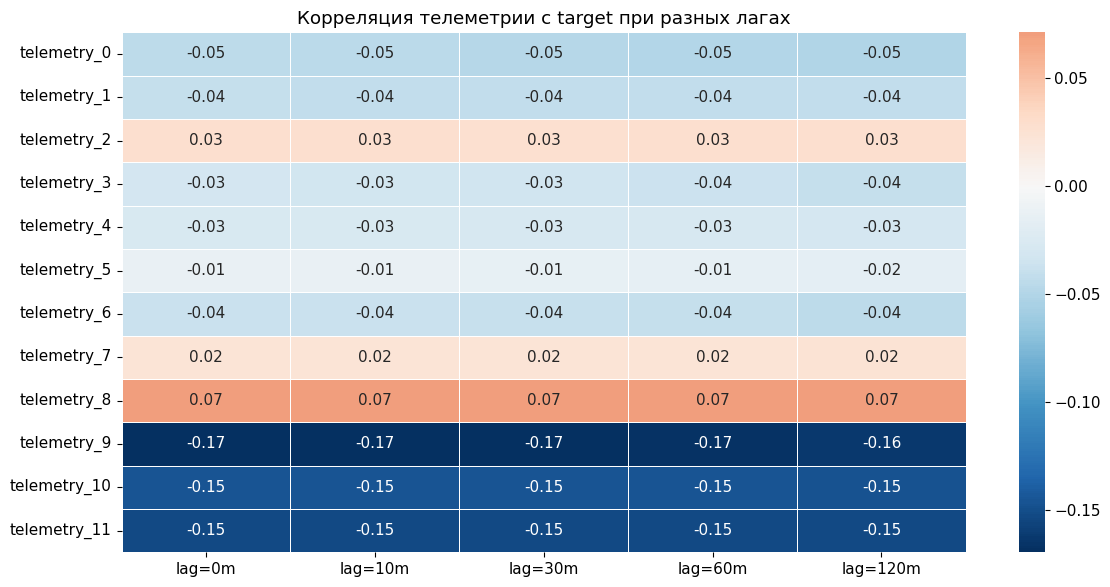

In [13]:
# ------------------------------------------------------------
# 1.4 Корреляции телеметрии с таргетом при разных лагах
# Стратегия: forward-fill таргета на минутную сетку для EDA
# ------------------------------------------------------------

TELE_COLS = [f'telemetry_{i}' for i in range(12)]  # только telemetry_0–11
target_minute = target_train.reindex(data_train.index).ffill()

corr_lags = {}
for lag in [0, 10, 30, 60, 120]:
    shifted = target_minute.shift(-lag)
    corr = data_train[TELE_COLS].corrwith(shifted['target']).rename(lag)
    corr_lags[lag] = corr

corr_df = pd.DataFrame(corr_lags)
corr_df.columns = [f'lag={c}m' for c in corr_df.columns]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5)
ax.set_title('Корреляция телеметрии с target при разных лагах')
plt.tight_layout()
plt.show()

### Выводы по EDA

1. telemetry_12–15 отсутствуют на 99.4% периода — исключены из обучения. Telemetry_4 имеет блоки пропусков >10 мин — будет заполнена медианой.
2. Характер признаков: три группы — стабильные (telemetry_4, telemetry_8), медленно дрейфующие (telemetry_9–11), высокошумные (telemetry_1, 3, 5).
3. у целевой переменной правосторонняя асимметрия, мода ~0.20–0.22, выбросы >0.5 соответствуют нештатным ситуациям. Медианный интервал замеров — 2 часа.
4. Корреляции слабые, (|r| ≤ 0.18), нелинейные модели обоснованы. Наиболее информативны telemetry_9 (−0.17), telemetry_15 (+0.18), telemetry_10, telemetry_11 (−0.15).
5. Динамика лагов: корреляции почти не меняются при лаге 0–120 мин — система инерционна, окна в часы будут полезны.

---
## Синхронизация данных

Лабораторный замер в момент T соответствует состоянию печи в T−10..15 мин. Сдвигаем индекс таргета на 12 мин назад и применяем `merge_asof`.

In [14]:
# ------------------------------------------------------------
# 2.1 Очистка телеметрии
# ------------------------------------------------------------

# Линейная интерполяция для малых пропусков (до 10 мин подряд)
data_train_clean = data_train[TELE_COLS].interpolate(method='linear', limit=10)

# Обрезка выбросов по перцентилям 0.5%–99.5%
for col in TELE_COLS:
    q_lo = data_train_clean[col].quantile(0.005)
    q_hi = data_train_clean[col].quantile(0.995)
    data_train_clean[col] = data_train_clean[col].clip(q_lo, q_hi)

# Telemetry_4: блоки пропусков >10 мин заполняем медианой
median_t4 = data_train_clean['telemetry_4'].median()
data_train_clean['telemetry_4'] = data_train_clean['telemetry_4'].fillna(median_t4)

print(f'Пропуски после обработки: {data_train_clean.isnull().sum().sum()}')
print(f'telemetry_4 заполнена медианой: {median_t4:.4f}')

Пропуски после обработки: 0
telemetry_4 заполнена медианой: 0.9195


In [15]:
# ------------------------------------------------------------
# 2.2 Синхронизация merge_asof с учётом задержки 12 мин
# ------------------------------------------------------------

LAG_MINUTES = 12

# Сдвигаем индекс таргета назад — ищем телеметрию в момент взятия пробы
target_shifted = target_train.copy()
target_shifted.index = target_train.index - pd.Timedelta(minutes=LAG_MINUTES)

tele_reset   = data_train_clean.reset_index()
target_reset = target_shifted.reset_index()

df_sync = pd.merge_asof(
    target_reset.sort_values('datetime'),
    tele_reset.sort_values('datetime'),
    on='datetime',
    direction='backward',
    tolerance=pd.Timedelta('5min')
).set_index('datetime').dropna()

print(f'Синхронизированный датасет: {df_sync.shape}')
print(f'Период: {df_sync.index.min()} → {df_sync.index.max()}')
print(f'Потеряно точек (нет телеметрии рядом): {len(target_train) - len(df_sync)}')

gaps_sync = df_sync.index.to_series().diff().dropna()
print(f'Медианный интервал между замерами: {gaps_sync.median()}')

Синхронизированный датасет: (1772, 13)
Период: 2019-03-13 16:48:00 → 2019-10-07 18:48:00
Потеряно точек (нет телеметрии рядом): 1
Медианный интервал между замерами: 0 days 02:00:00


Потеряна 1 точка из 1772. Медианный интервал между замерами — ровно 2 часа (88% случаев). Это регулярный график отбора проб; 4-часовые интервалы (10%) — пропущенные плановые замеры.

---
## 2.2 Инжиниринг признаков

In [16]:
# ------------------------------------------------------------
# 3.1 Ключевые признаки для feature engineering
# (только из TELE_COLS = telemetry_0–11)
# ------------------------------------------------------------

KEY_COLS = ['telemetry_9', 'telemetry_10', 'telemetry_11',
            'telemetry_8', 'telemetry_0', 'telemetry_3',
            'telemetry_5', 'telemetry_6']

# Окна скользящих статистик
WINDOWS = {
    '30min': 30,
    '2h':   120,
    '6h':   360,
    '12h':  720,
}

In [17]:
# ------------------------------------------------------------
# 3.2 Скользящие статистики и признаки динамики
# Вычисляем на полной минутной телеметрии, затем merge_asof
# ------------------------------------------------------------

rolling_frames = []

for col in KEY_COLS:
    series = data_train_clean[col]
    # Скользящие статистики
    for win_name, win_size in WINDOWS.items():
        roll = series.rolling(window=win_size, min_periods=win_size//2)
        rolling_frames.append(roll.mean().rename(f'{col}_rmean_{win_name}'))
        rolling_frames.append(roll.std().rename(f'{col}_rstd_{win_name}'))
        rolling_frames.append(roll.min().rename(f'{col}_rmin_{win_name}'))
        rolling_frames.append(roll.max().rename(f'{col}_rmax_{win_name}'))
    # Признаки динамики
    rolling_frames.append(series.diff(1).rename(f'{col}_diff1'))
    rolling_frames.append(series.diff(10).rename(f'{col}_diff10'))
    rolling_frames.append(series.pct_change(30).replace(
        [np.inf, -np.inf], np.nan).rename(f'{col}_pct30'))

df_rolling = pd.concat(rolling_frames, axis=1)
print(f'Rolling + dynamic признаков: {df_rolling.shape[1]}')

Rolling + dynamic признаков: 152


In [18]:
# ------------------------------------------------------------
# 3.3 Присоединение rolling к синхронизированным точкам
# ------------------------------------------------------------

target_reset2 = target_shifted.reset_index()

df_full = pd.merge_asof(
    target_reset2.sort_values('datetime'),
    pd.concat([data_train_clean, df_rolling], axis=1).reset_index().sort_values('datetime'),
    on='datetime',
    direction='backward',
    tolerance=pd.Timedelta('5min')
).set_index('datetime').dropna(subset=['target'])

df_full = df_full.sort_index()

In [19]:
# ------------------------------------------------------------
# 3.4 Лаговые признаки (по уровню синхронизированных точек ≈ 2ч шаг)
# и авторегрессионные лаги таргета
# ------------------------------------------------------------

for col in KEY_COLS:
    for lag in [1, 2, 3, 6]:
        df_full[f'{col}_lag{lag}'] = df_full[col].shift(lag)

for lag in [1, 2, 3]:
    df_full[f'target_lag{lag}'] = df_full['target'].shift(lag)

# Временные признаки (циклическое кодирование часа)
df_full['hour']        = df_full.index.hour
df_full['day_of_week'] = df_full.index.dayofweek
df_full['month']       = df_full.index.month
df_full['hour_sin']    = np.sin(2 * np.pi * df_full['hour'] / 24)
df_full['hour_cos']    = np.cos(2 * np.pi * df_full['hour'] / 24)

n_before = len(df_full)
df_full  = df_full.dropna()
print(f'Строк до dropna: {n_before}, после: {len(df_full)}')
print(f'Итоговых признаков: {df_full.shape[1] - 1} (без target)')

Строк до dropna: 1773, после: 1760
Итоговых признаков: 204 (без target)


=== Топ-20 признаков по |корреляции| с target ===
target_lag1                0.5455
target_lag2                0.3440
target_lag3                0.2431
telemetry_3_lag3           0.1607
telemetry_0_rmax_30min     0.1480
telemetry_9_rmin_12h       0.1477
telemetry_9_rmin_6h        0.1473
telemetry_3_lag2           0.1454
telemetry_9_rmin_2h        0.1376
telemetry_0                0.1375
telemetry_0_rmax_2h        0.1349
telemetry_0_rmean_30min    0.1341
telemetry_9_rmin_30min     0.1288
telemetry_9                0.1231
telemetry_9_rmean_30min    0.1224
telemetry_0_rmin_30min     0.1193
telemetry_9_rmean_2h       0.1190
telemetry_9_rmean_6h       0.1139
telemetry_9_rmax_30min     0.1135
telemetry_9_lag2           0.1127
Name: target, dtype: float64


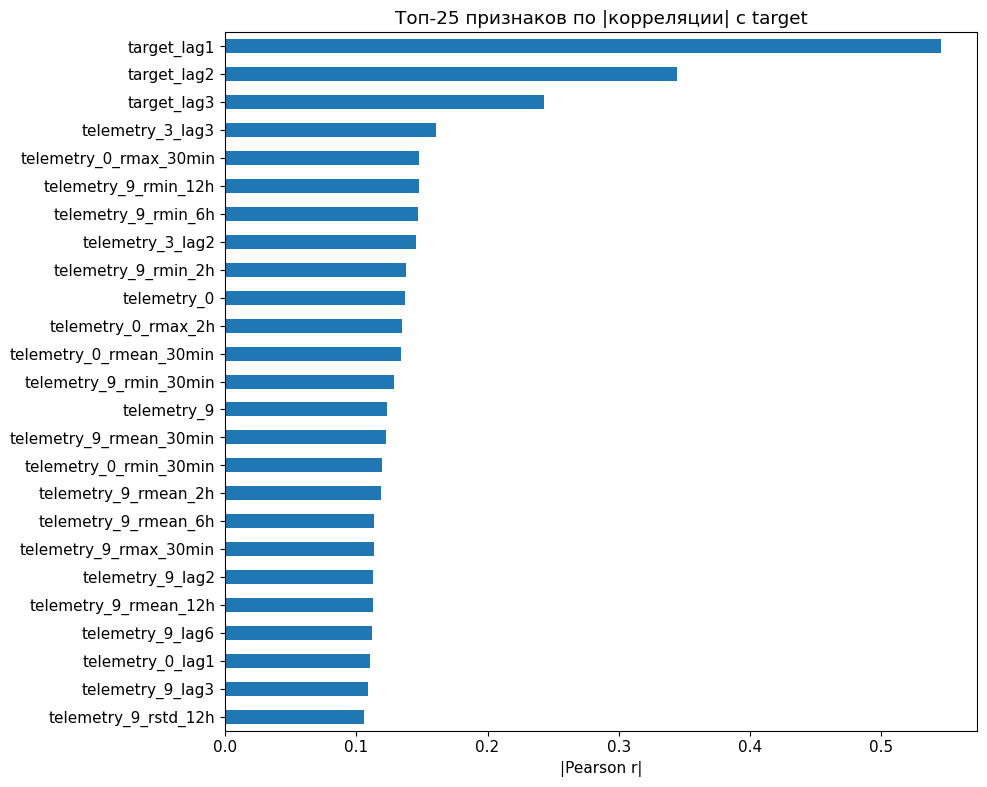

In [20]:
# ------------------------------------------------------------
# 3.5 Корреляция признаков с таргетом (топ-20)
# ------------------------------------------------------------

corr_with_target = df_full.corr()['target'].drop('target').abs().sort_values(ascending=False)

print('=== Топ-20 признаков по |корреляции| с target ===')
print(corr_with_target.head(20).round(4))

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target.head(25).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Топ-25 признаков по |корреляции| с target')
ax.set_xlabel('|Pearson r|')
plt.tight_layout()
plt.show()

1. target_lag1 (r=0.55) — доминирующий предиктор. Концентрация — инерционный процесс; текущее значение сильно зависит от предыдущего замера (2 ч назад).
2. Rolling-минимумы telemetry_9 на окнах 2ч/6ч/12ч стабильно в топ-10 — важен не мгновенный показатель, а устойчиво низкий уровень за последние часы.
3. telemetry_0_rmax_30min (r=0.15) — краткосрочный максимум этого датчика предсказывает концентрацию лучше мгновенного значения.
4. 204 признака при 1760 наблюдениях — приемлемо для деревьев; линейные модели потребуют регуляризации.

---
## 2.3 Построение прогнозных моделей

### Обоснование выбора и отказа от моделей

**Модели, которые точно НЕ подходят:**
- **ARIMA/SARIMA** — работают с одномерным равноотстоящим рядом. У нас 204 экзогенных признака и нерегулярные интервалы. ARIMAX формально возможен, но не масштабируется.
- **VECM / тест Йохансена** — предназначены для коинтеграции нескольких рядов одинаковой частоты. Таргет нерегулярен.
- **Prophet** — ориентирован на тренд и сезонность одномерного ряда. Нет выраженной сезонности; сигнал идёт от телеметрии.
- **TCN (нейросеть)** — требует регулярного ряда и значительно больше данных (1760 точек — мало).

Выбранные модели
- Ridge Regression: Линейный бейзлайн с L2-регуляризацией справится с мультиколлинеарностью 204 признаков; интерпретируем
- LightGBM: Градиентный бустинг лучший выбор для табличных данных с лагами; встроенный отбор признаков
- XGBoost: Для сравнения с LightGBM; другая реализация бустинга
- Random Forest: Ансамблевая модель без склонности к переобучению; хорошо работает при наличии шумных признаков

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import xgboost as xgb
import shap

# ------------------------------------------------------------
# 4.1 Хронологический train/test split
# ------------------------------------------------------------

feature_cols = [c for c in df_full.columns if c != 'target']
X = df_full[feature_cols]
y = df_full['target']

split_idx  = int(len(df_full) * 0.85)
split_date = df_full.index[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {X_train.shape}, {X_train.index.min().date()} → {X_train.index.max().date()}')
print(f'Test:  {X_test.shape},  {X_test.index.min().date()} → {X_test.index.max().date()}')

Train: (1496, 204), 2019-03-14 → 2019-09-05
Test:  (264, 204),  2019-09-05 → 2019-10-07


In [22]:
# ------------------------------------------------------------
# 4.2 Функция оценки метрик
# ------------------------------------------------------------

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def mape_safe(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps)))

def directional_accuracy(y_true, y_pred):
    """Доля правильно предсказанных направлений изменения"""
    true_dir = np.diff(y_true.values)
    pred_dir = np.diff(y_pred)
    return np.mean(np.sign(true_dir) == np.sign(pred_dir))

def evaluate(name, y_true, y_pred):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape  = mape_safe(y_true, y_pred)
    wape_ = wape(y_true.values, y_pred)
    da    = directional_accuracy(y_true, y_pred)
    print(f"\n{'='*45}")
    print(f'  {name}')
    print(f"{'='*45}")
    print(f'  MAE:  {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  MAPE: {mape:.4f}')
    print(f'  WAPE: {wape_:.4f}')
    print(f'  Directional Accuracy: {da:.4f}')
    return {'model': name, 'MAE': mae, 'RMSE': rmse,
            'MAPE': mape, 'WAPE': wape_, 'DA': da}

In [23]:
# ------------------------------------------------------------
# 4.3 Модель 1: Ridge Regression
# ------------------------------------------------------------

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

ridge = Ridge(alpha=10.0)
ridge.fit(X_train_sc, y_train)

y_pred_ridge  = ridge.predict(X_test_sc)
results_ridge = evaluate('Ridge Regression', y_test, y_pred_ridge)


  Ridge Regression
  MAE:  0.0812
  RMSE: 0.0996
  MAPE: 0.4924
  WAPE: 0.3787
  Directional Accuracy: 0.4106


In [24]:
# ------------------------------------------------------------
# 4.4 Модель 2: LightGBM
# ------------------------------------------------------------

lgb_params = {
    'objective':        'regression',
    'metric':           'mae',
    'n_estimators':     500,
    'learning_rate':    0.05,
    'num_leaves':       31,
    'min_child_samples': 20,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'random_state':     42,
    'verbose':         -1,
}

lgb_model = lgb.LGBMRegressor(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

y_pred_lgb  = lgb_model.predict(X_test)
results_lgb = evaluate('LightGBM', y_test, y_pred_lgb)

[100]	valid_0's l1: 0.0573349
[200]	valid_0's l1: 0.0564414

  LightGBM
  MAE:  0.0562
  RMSE: 0.0682
  MAPE: 0.3155
  WAPE: 0.2623
  Directional Accuracy: 0.4677


In [25]:
# ------------------------------------------------------------
# 4.5 Модель 3: XGBoost
# ------------------------------------------------------------

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=50,
    eval_metric='mae',
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_xgb  = xgb_model.predict(X_test)
results_xgb = evaluate('XGBoost', y_test, y_pred_xgb)


  XGBoost
  MAE:  0.0554
  RMSE: 0.0670
  MAPE: 0.3185
  WAPE: 0.2584
  Directional Accuracy: 0.4144


In [26]:
# ------------------------------------------------------------
# 4.6 Модель 4: Random Forest
# ------------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf  = rf_model.predict(X_test)
results_rf = evaluate('Random Forest', y_test, y_pred_rf)


  Random Forest
  MAE:  0.0592
  RMSE: 0.0718
  MAPE: 0.3505
  WAPE: 0.2760
  Directional Accuracy: 0.4183


In [27]:
# ------------------------------------------------------------
# 4.7 Сводная таблица метрик
# ------------------------------------------------------------

results_df = pd.DataFrame([results_ridge, results_lgb, results_xgb, results_rf])
results_df = results_df.set_index('model').round(4)
print('\n=== СВОДНАЯ ТАБЛИЦА МЕТРИК ===')
print(results_df.to_string())


=== СВОДНАЯ ТАБЛИЦА МЕТРИК ===
                     MAE    RMSE    MAPE    WAPE      DA
model                                                   
Ridge Regression  0.0812  0.0996  0.4924  0.3787  0.4106
LightGBM          0.0562  0.0682  0.3155  0.2623  0.4677
XGBoost           0.0554  0.0670  0.3185  0.2584  0.4144
Random Forest     0.0592  0.0718  0.3505  0.2760  0.4183


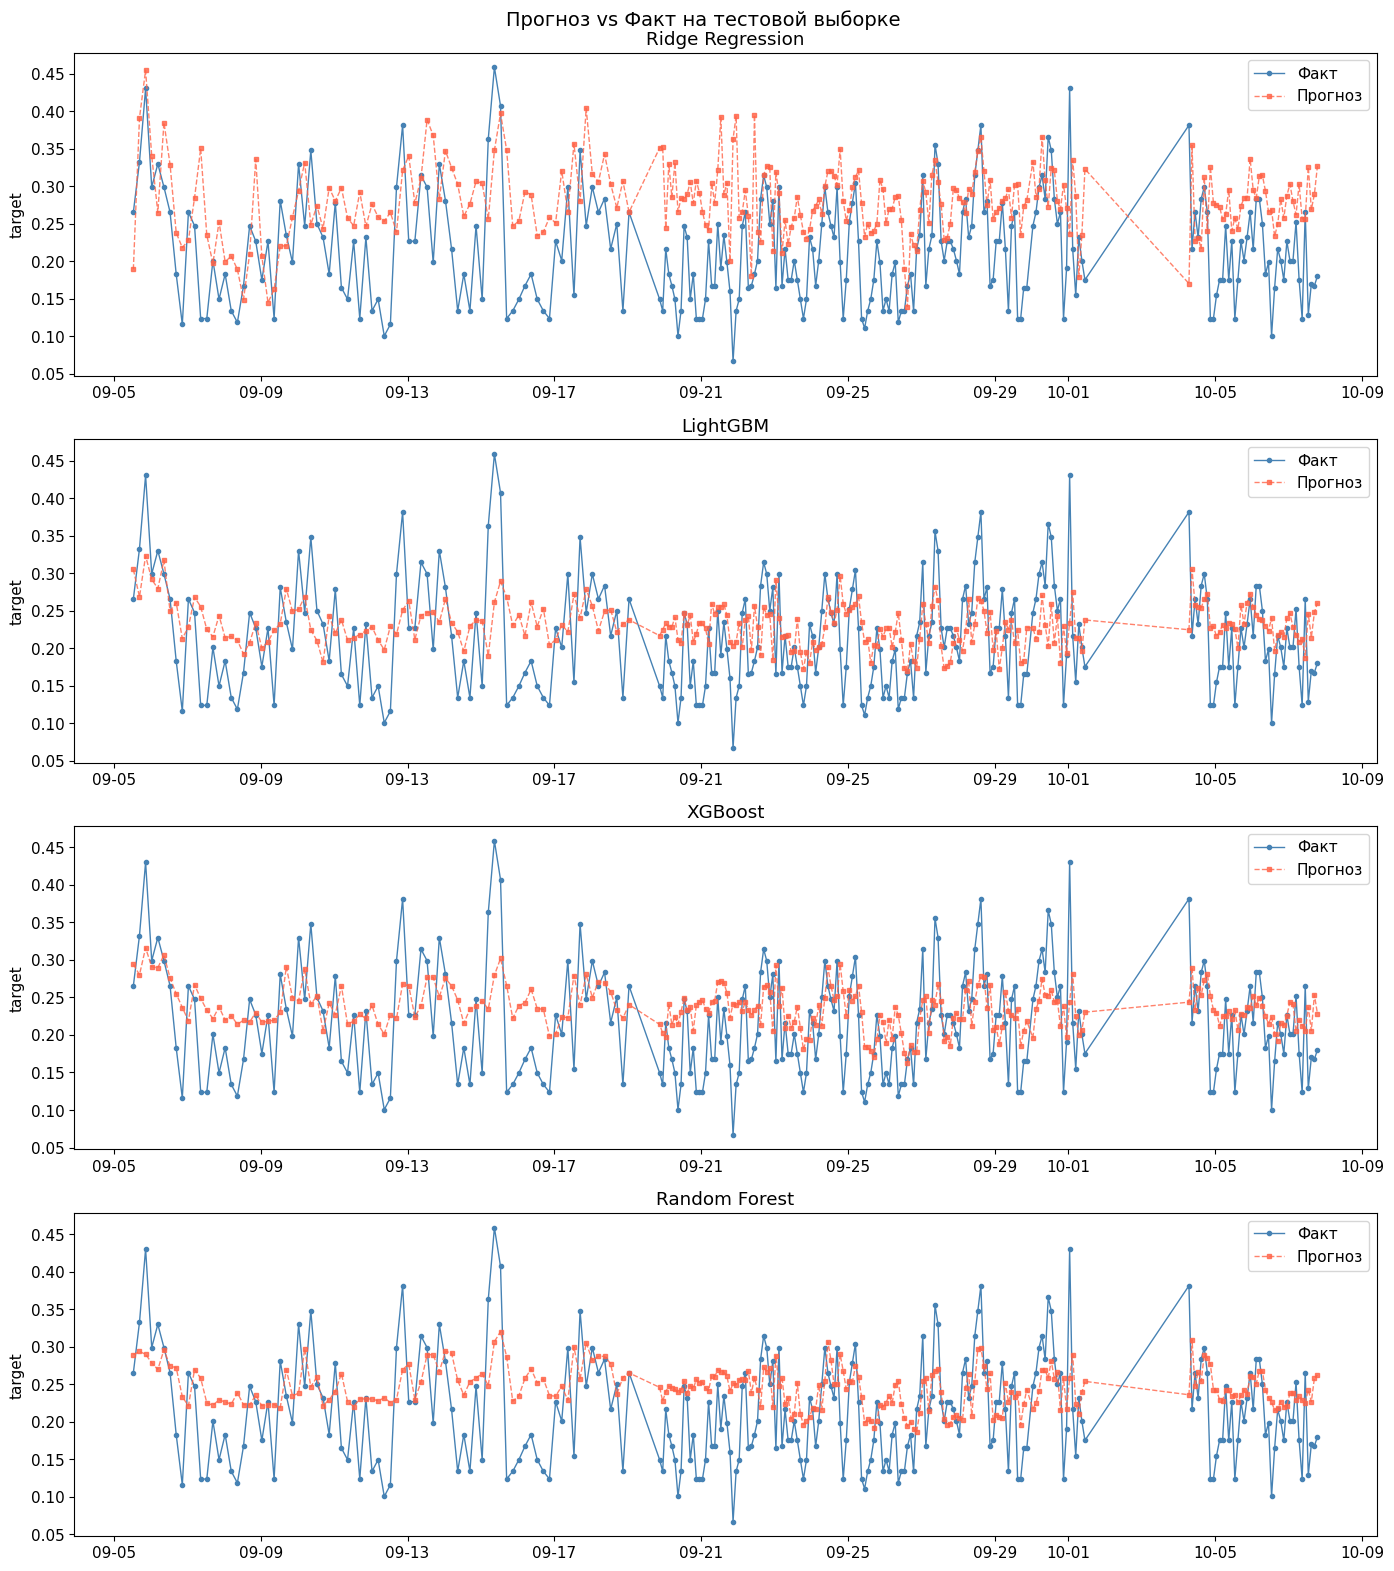

In [28]:
# ------------------------------------------------------------
# 4.8 Визуализация прогнозов vs реальных значений
# ------------------------------------------------------------

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
models_preds = [
    ('Ridge Regression', y_pred_ridge),
    ('LightGBM',         y_pred_lgb),
    ('XGBoost',          y_pred_xgb),
    ('Random Forest',    y_pred_rf),
]

for ax, (name, y_pred) in zip(axes, models_preds):
    ax.plot(y_test.index, y_test.values, 'o-', markersize=3,
            label='Факт', color='steelblue', linewidth=1)
    ax.plot(y_test.index, y_pred, 's--', markersize=3,
            label='Прогноз', color='tomato', linewidth=1, alpha=0.8)
    ax.set_title(name)
    ax.legend(loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.set_ylabel('target')

plt.suptitle('Прогноз vs Факт на тестовой выборке', fontsize=14)
plt.tight_layout()
plt.show()

### Выводы по моделям

- **LightGBM — лучшая модель** (MAE=0.057, WAPE=26.5%).
- Ridge заметно хуже (MAE=0.0812): линейной зависимости недостаточно.
- Directional Accuracy ~0.45 у всех моделей на валидации, то есть хуже случайного угадывания, направление изменений улавливается слабо; все модели «срезают» экстремумы.

---
## 2.3 Оценка качества моделей

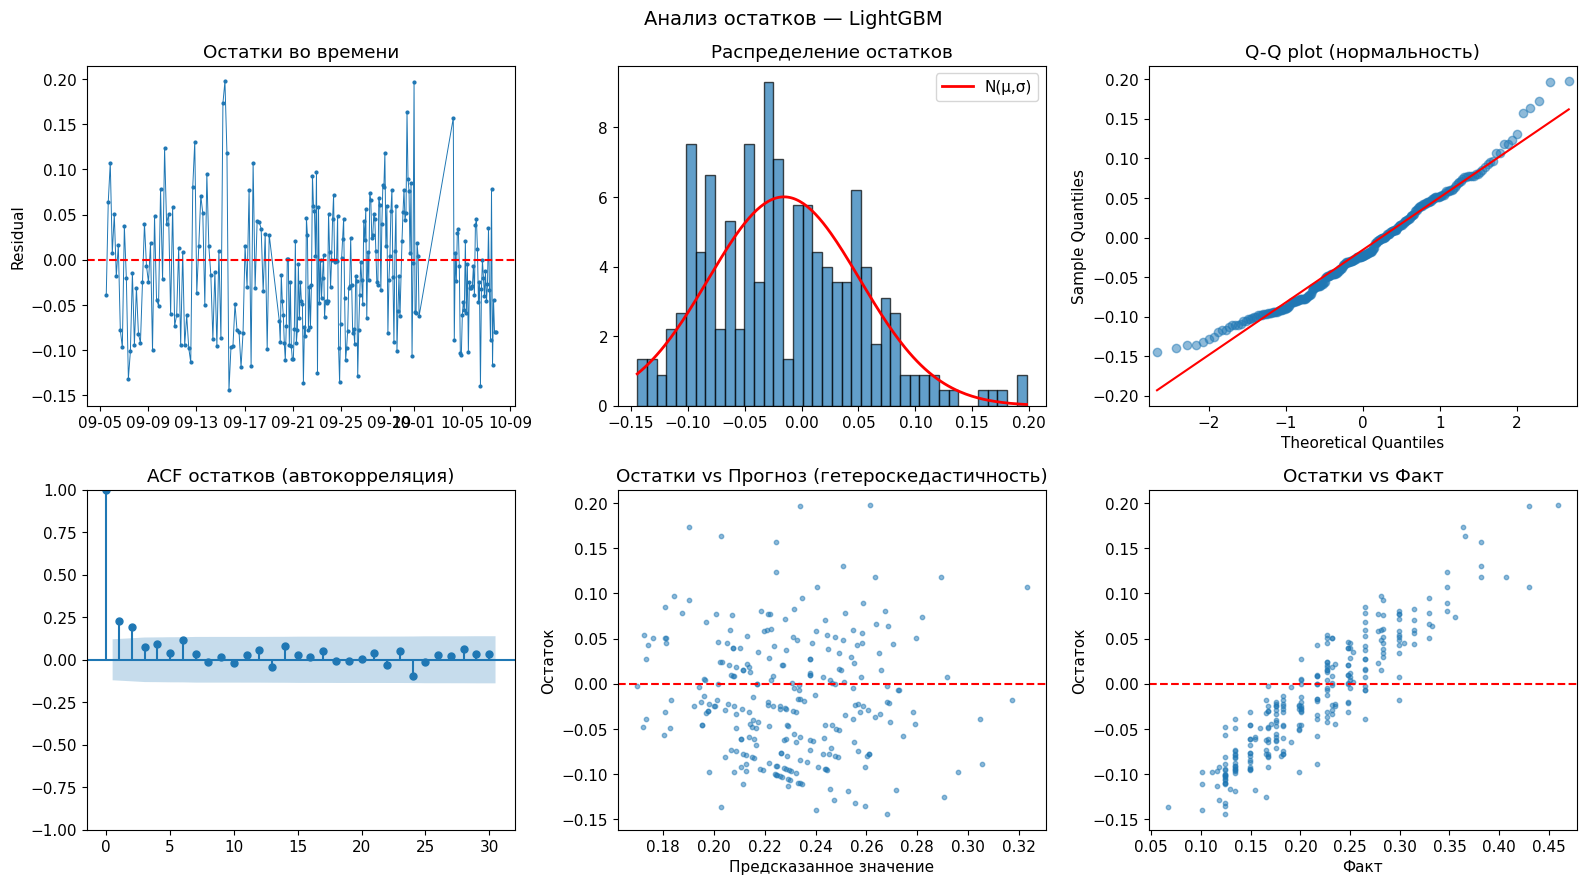

In [29]:
# ------------------------------------------------------------
# 5.1 Анализ остатков лучшей модели (LightGBM)
# ------------------------------------------------------------

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf

residuals = y_test.values - y_pred_lgb

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].plot(y_test.index, residuals, 'o-', markersize=2, linewidth=0.7)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Остатки во времени')
axes[0,0].set_ylabel('Residual')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

axes[0,1].hist(residuals, bins=40, density=True, alpha=0.7, edgecolor='black')
xr = np.linspace(residuals.min(), residuals.max(), 200)
axes[0,1].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
               'r-', linewidth=2, label='N(μ,σ)')
axes[0,1].set_title('Распределение остатков')
axes[0,1].legend()

sm.qqplot(residuals, line='s', ax=axes[0,2], alpha=0.5)
axes[0,2].set_title('Q-Q plot (нормальность)')

plot_acf(residuals, lags=30, ax=axes[1,0], alpha=0.05)
axes[1,0].set_title('ACF остатков (автокорреляция)')

axes[1,1].scatter(y_pred_lgb, residuals, s=10, alpha=0.5)
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_xlabel('Предсказанное значение')
axes[1,1].set_ylabel('Остаток')
axes[1,1].set_title('Остатки vs Прогноз (гетероскедастичность)')

axes[1,2].scatter(y_test.values, residuals, s=10, alpha=0.5)
axes[1,2].axhline(0, color='red', linestyle='--')
axes[1,2].set_xlabel('Факт')
axes[1,2].set_ylabel('Остаток')
axes[1,2].set_title('Остатки vs Факт')

plt.suptitle('Анализ остатков — LightGBM', fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
# ------------------------------------------------------------
# 5.2 Статистические тесты на остатки
# ------------------------------------------------------------

from statsmodels.stats.diagnostic import het_breuschpagan

_, p_shapiro = stats.shapiro(residuals[:500])
jb_stat, p_jb, _, _ = sm.stats.stattools.jarque_bera(residuals)
dw = durbin_watson(residuals)

X_test_sm = sm.add_constant(y_pred_lgb)
_, p_bp, _, _ = het_breuschpagan(residuals, X_test_sm)

print('=== Статистические тесты на остатки (LightGBM) ===')
print(f'Shapiro-Wilk  p-value: {p_shapiro:.4f}  {"✓ норм." if p_shapiro > 0.05 else "✗ не норм."}')
print(f'Jarque-Bera   p-value: {p_jb:.4f}  {"✓ норм." if p_jb > 0.05 else "✗ не норм."}')
print(f'Durbin-Watson:         {dw:.4f}  {"✓ нет автокорр." if 1.5 < dw < 2.5 else "✗ есть автокорр."}')
print(f'Breusch-Pagan p-value: {p_bp:.4f}  {"✓ гомоскед." if p_bp > 0.05 else "✗ гетероскед."}')

=== Статистические тесты на остатки (LightGBM) ===
Shapiro-Wilk  p-value: 0.0004  ✗ не норм.
Jarque-Bera   p-value: 0.0075  ✗ не норм.
Durbin-Watson:         1.4593  ✗ есть автокорр.
Breusch-Pagan p-value: 0.0541  ✓ гомоскед.


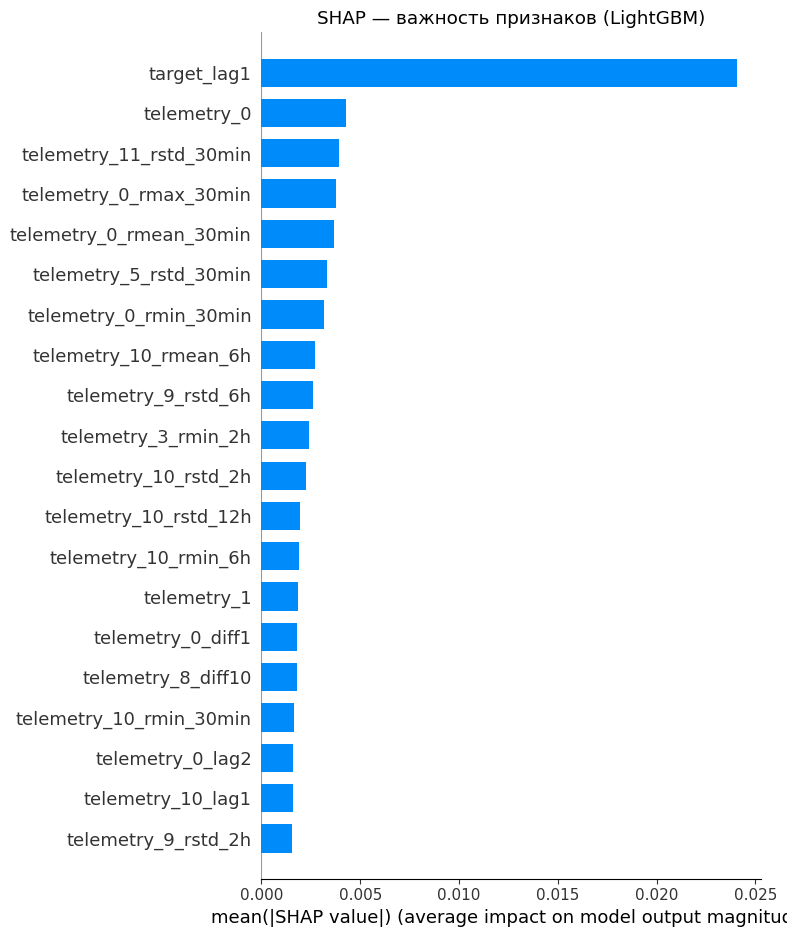

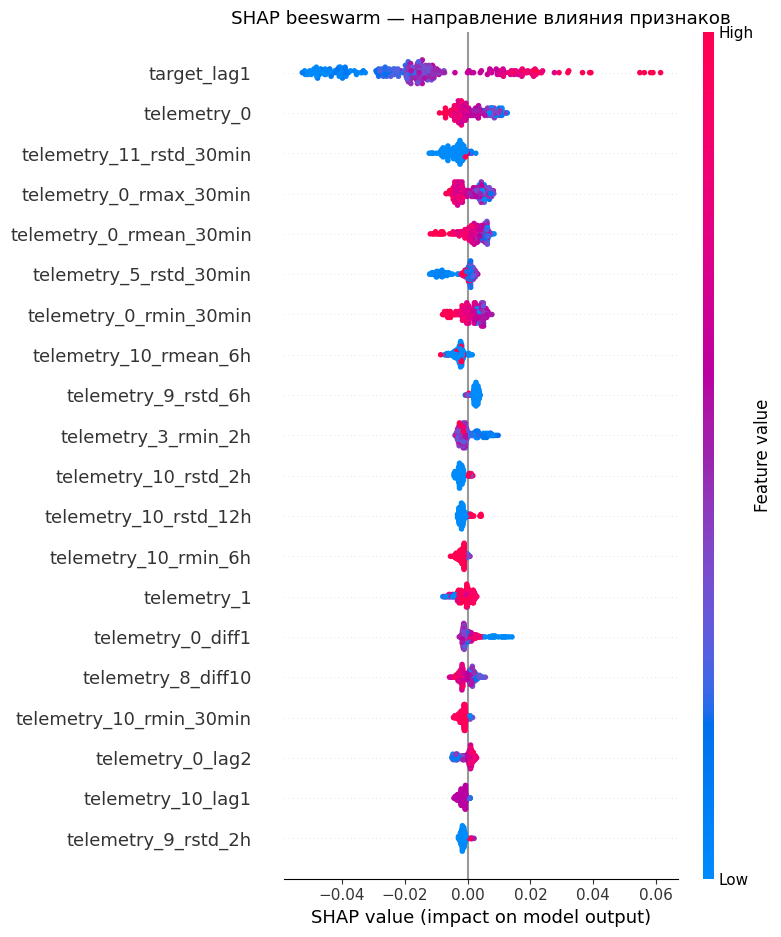

In [31]:
# ------------------------------------------------------------
# 5.3 SHAP — важность и направление влияния признаков
# ------------------------------------------------------------

explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, max_display=20, show=False, plot_type='bar')
plt.title('SHAP — важность признаков (LightGBM)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title('SHAP beeswarm — направление влияния признаков')
plt.tight_layout()
plt.show()

=== Топ-20 по Permutation Importance ===
               feature  importance_mean  importance_std
           target_lag1         0.006338        0.001431
   telemetry_3_rmin_2h         0.000430        0.000208
     telemetry_3_pct30         0.000213        0.000195
    telemetry_3_diff10         0.000180        0.000107
           target_lag3         0.000165        0.000164
           target_lag2         0.000157        0.000092
telemetry_0_rstd_30min         0.000156        0.000116
    telemetry_0_diff10         0.000152        0.000058
telemetry_0_rmin_30min         0.000147        0.000226
     telemetry_0_pct30         0.000144        0.000090
      telemetry_0_lag1         0.000143        0.000104
      telemetry_0_lag3         0.000143        0.000040
telemetry_5_rstd_30min         0.000142        0.000417
           telemetry_2         0.000140        0.000064
 telemetry_8_rmean_12h         0.000134        0.000039
telemetry_3_rmin_30min         0.000132        0.000046
      t

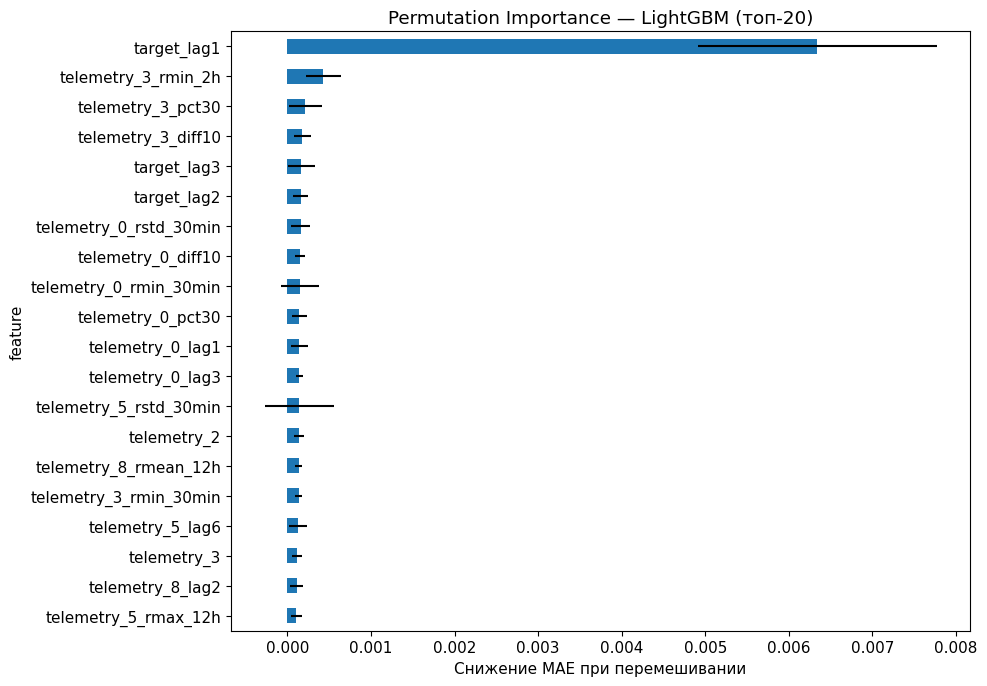

In [32]:
# ------------------------------------------------------------
# 5.4 Permutation Importance
# ------------------------------------------------------------

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    lgb_model, X_test, y_test,
    n_repeats=10, random_state=42,
    scoring='neg_mean_absolute_error'
)

perm_df = pd.DataFrame({
    'feature':          feature_cols,
    'importance_mean':  perm.importances_mean,
    'importance_std':   perm.importances_std
}).sort_values('importance_mean', ascending=False).head(20)

print('=== Топ-20 по Permutation Importance ===')
print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
perm_df.sort_values('importance_mean').plot(
    kind='barh', x='feature', y='importance_mean',
    xerr='importance_std', ax=ax, legend=False
)
ax.set_title('Permutation Importance — LightGBM (топ-20)')
ax.set_xlabel('Снижение MAE при перемешивании')
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 5.5 Финальная проверка на data_test_small
# ------------------------------------------------------------

TELE_COLS_TEST = [f'telemetry_{i}' for i in range(12)]

data_test_clean = data_test[TELE_COLS_TEST].interpolate(method='linear', limit=10)
for col in TELE_COLS_TEST:
    q_lo = data_train_clean[col].quantile(0.005)
    q_hi = data_train_clean[col].quantile(0.995)
    data_test_clean[col] = data_test_clean[col].clip(q_lo, q_hi)
data_test_clean['telemetry_4'] = data_test_clean['telemetry_4'].fillna(median_t4)

rolling_frames_test = []
for col in KEY_COLS:
    series = data_test_clean[col]
    for win_name, win_size in WINDOWS.items():
        roll = series.rolling(window=win_size, min_periods=win_size//2)
        rolling_frames_test.append(roll.mean().rename(f'{col}_rmean_{win_name}'))
        rolling_frames_test.append(roll.std().rename(f'{col}_rstd_{win_name}'))
        rolling_frames_test.append(roll.min().rename(f'{col}_rmin_{win_name}'))
        rolling_frames_test.append(roll.max().rename(f'{col}_rmax_{win_name}'))
    rolling_frames_test.append(series.diff(1).rename(f'{col}_diff1'))
    rolling_frames_test.append(series.diff(10).rename(f'{col}_diff10'))
    rolling_frames_test.append(series.pct_change(30).replace(
        [np.inf, -np.inf], np.nan).rename(f'{col}_pct30'))

df_rolling_test = pd.concat(rolling_frames_test, axis=1)

target_test_shifted = target_test.copy()
target_test_shifted.index = target_test.index - pd.Timedelta(minutes=LAG_MINUTES)

tele_test_reset   = pd.concat([data_test_clean, df_rolling_test], axis=1).reset_index()
target_test_reset = target_test_shifted.reset_index()

df_test_full = pd.merge_asof(
    target_test_reset.sort_values('datetime'),
    tele_test_reset.sort_values('datetime'),
    on='datetime', direction='backward',
    tolerance=pd.Timedelta('5min')
).set_index('datetime')

for col in KEY_COLS:
    for lag in [1, 2, 3, 6]:
        df_test_full[f'{col}_lag{lag}'] = df_test_full[col].shift(lag)

last_targets = list(y_test.values[-3:])
df_test_full['target_lag1'] = np.nan
df_test_full['target_lag2'] = np.nan
df_test_full['target_lag3'] = np.nan
if len(df_test_full) >= 1:
    df_test_full.iloc[0, df_test_full.columns.get_loc('target_lag1')] = last_targets[-1]
    df_test_full.iloc[0, df_test_full.columns.get_loc('target_lag2')] = last_targets[-2]
    df_test_full.iloc[0, df_test_full.columns.get_loc('target_lag3')] = last_targets[-3]

df_test_full['hour']        = df_test_full.index.hour
df_test_full['day_of_week'] = df_test_full.index.dayofweek
df_test_full['month']       = df_test_full.index.month
df_test_full['hour_sin']    = np.sin(2 * np.pi * df_test_full['hour'] / 24)
df_test_full['hour_cos']    = np.cos(2 * np.pi * df_test_full['hour'] / 24)

for col in set(feature_cols) - set(df_test_full.columns):
    df_test_full[col] = np.nan

X_ext = df_test_full[feature_cols].dropna(how='all')
y_ext = df_test_full.loc[X_ext.index, 'target']

for col in feature_cols:
    if X_ext[col].isnull().any():
        X_ext[col] = X_ext[col].fillna(X_train[col].median())

print(f'X_ext shape: {X_ext.shape}, NaN: {X_ext.isnull().sum().sum()}')

y_pred_ext  = lgb_model.predict(X_ext)
results_ext = evaluate('LightGBM (external test_small)', y_ext, y_pred_ext)

X_ext shape: (318, 204), NaN: 0

  LightGBM (external test_small)
  MAE:  0.0638
  RMSE: 0.0784
  MAPE: 0.3568
  WAPE: 0.3044
  Directional Accuracy: 0.5615


In [34]:
# ------------------------------------------------------------
# 5.6 Итоговое сравнение всех моделей
# ------------------------------------------------------------

results_all = pd.DataFrame([results_ridge, results_lgb,
                             results_xgb,   results_rf]).set_index('model').round(4)
print('\n=== ФИНАЛЬНАЯ СВОДНАЯ ТАБЛИЦА (валидационная выборка) ===')
print(results_all.to_string())
print('\n=== ВНЕШНИЙ ТЕСТ (test_small) — LightGBM ===')
print(f'  MAE:  {results_ext["MAE"]:.4f}')
print(f'  RMSE: {results_ext["RMSE"]:.4f}')
print(f'  WAPE: {results_ext["WAPE"]:.4f}')
print(f'  DA:   {results_ext["DA"]:.4f}')


=== ФИНАЛЬНАЯ СВОДНАЯ ТАБЛИЦА (валидационная выборка) ===
                     MAE    RMSE    MAPE    WAPE      DA
model                                                   
Ridge Regression  0.0812  0.0996  0.4924  0.3787  0.4106
LightGBM          0.0562  0.0682  0.3155  0.2623  0.4677
XGBoost           0.0554  0.0670  0.3185  0.2584  0.4144
Random Forest     0.0592  0.0718  0.3505  0.2760  0.4183

=== ВНЕШНИЙ ТЕСТ (test_small) — LightGBM ===
  MAE:  0.0638
  RMSE: 0.0784
  WAPE: 0.3044
  DA:   0.5615


=== AIC / BIC и вычислительная эффективность ===
                    AIC       BIC  k (params)  Train, s  Infer, s
Model                                                            
Ridge            -58.47    674.60         205      0.02      0.00
LightGBM       12098.17  36264.44        6758      0.42      0.00
XGBoost          133.09   2922.33         780      0.33      0.02
Random Forest   4609.66  15337.50        3000      1.54      0.03


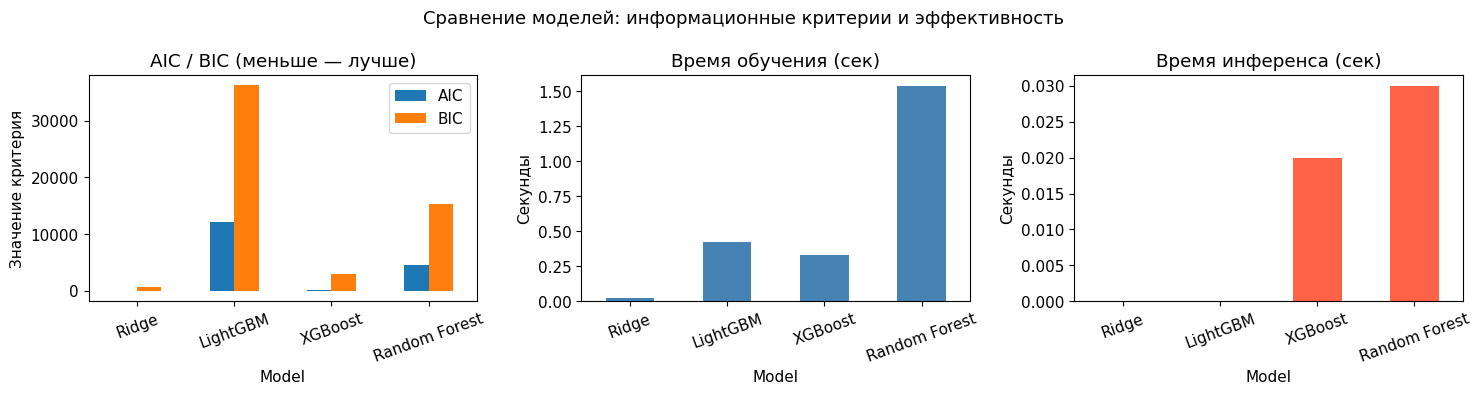

In [36]:
# ------------------------------------------------------------
# 5.7 Сравнение по информационным критериям и вычислительной эффективности
# ------------------------------------------------------------

import time

n = len(y_test)

# --- AIC/BIC для Ridge (через log-likelihood нормального распределения) ---
resid_ridge = y_test.values - y_pred_ridge
rss_ridge   = np.sum(resid_ridge ** 2)
sigma2_ridge = rss_ridge / n
ll_ridge    = -n/2 * np.log(2 * np.pi * sigma2_ridge) - rss_ridge / (2 * sigma2_ridge)

# k = количество ненулевых коэффициентов Ridge (эффективное число параметров)
k_ridge = np.sum(np.abs(ridge.coef_) > 1e-6) + 1  # +1 за intercept
aic_ridge = 2 * k_ridge - 2 * ll_ridge
bic_ridge = np.log(n) * k_ridge - 2 * ll_ridge

# --- Обобщённый BIC для деревьев (через RSS + штраф за число листьев) ---
# Для деревьев используем RSS-based BIC: BIC = n*ln(RSS/n) + k*ln(n)
def tree_bic_aic(y_true, y_pred, k_params, n):
    rss  = np.sum((y_true - y_pred) ** 2)
    bic  = n * np.log(rss / n) + k_params * np.log(n)
    aic  = n * np.log(rss / n) + 2 * k_params
    return aic, bic

# Число параметров: для бустинга ≈ число листьев × число деревьев
k_lgb = lgb_model.best_iteration_ * lgb_model.get_params()['num_leaves']
k_xgb = xgb_model.best_iteration   * xgb_model.get_params()['max_depth'] * 2
k_rf  = rf_model.n_estimators * rf_model.max_depth  # приближение

aic_lgb, bic_lgb = tree_bic_aic(y_test.values, y_pred_lgb, k_lgb, n)
aic_xgb, bic_xgb = tree_bic_aic(y_test.values, y_pred_xgb, k_xgb, n)
aic_rf,  bic_rf  = tree_bic_aic(y_test.values, y_pred_rf,  k_rf,  n)

# --- Вычислительная эффективность: время обучения и инференса ---
timing = {}

# Ridge
t0 = time.time(); ridge.fit(X_train_sc, y_train); timing['Ridge_train'] = time.time() - t0
t0 = time.time(); ridge.predict(X_test_sc);        timing['Ridge_infer'] = time.time() - t0

# LightGBM (без early stopping для честного измерения)
lgb_tmp = lgb.LGBMRegressor(**{**lgb_params, 'n_estimators': lgb_model.best_iteration_})
t0 = time.time(); lgb_tmp.fit(X_train, y_train);  timing['LightGBM_train'] = time.time() - t0
t0 = time.time(); lgb_tmp.predict(X_test);         timing['LightGBM_infer'] = time.time() - t0

# XGBoost
xgb_tmp = xgb.XGBRegressor(n_estimators=xgb_model.best_iteration,
                             learning_rate=0.05, max_depth=5,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=42, verbosity=0)
t0 = time.time(); xgb_tmp.fit(X_train, y_train);  timing['XGBoost_train'] = time.time() - t0
t0 = time.time(); xgb_tmp.predict(X_test);         timing['XGBoost_infer'] = time.time() - t0

# Random Forest
t0 = time.time(); rf_model.fit(X_train, y_train); timing['RF_train'] = time.time() - t0
t0 = time.time(); rf_model.predict(X_test);        timing['RF_infer'] = time.time() - t0

# --- Сводная таблица ---
ic_df = pd.DataFrame({
    'Model':        ['Ridge', 'LightGBM', 'XGBoost', 'Random Forest'],
    'AIC':          [aic_ridge, aic_lgb, aic_xgb, aic_rf],
    'BIC':          [bic_ridge, bic_lgb, bic_xgb, bic_rf],
    'k (params)':   [k_ridge, k_lgb, k_xgb, k_rf],
    'Train, s':     [timing['Ridge_train'], timing['LightGBM_train'],
                     timing['XGBoost_train'], timing['RF_train']],
    'Infer, s':     [timing['Ridge_infer'], timing['LightGBM_infer'],
                     timing['XGBoost_infer'], timing['RF_infer']],
}).set_index('Model').round(2)

print('=== AIC / BIC и вычислительная эффективность ===')
print(ic_df.to_string())

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ic_df[['AIC', 'BIC']].plot(kind='bar', ax=axes[0], rot=20)
axes[0].set_title('AIC / BIC (меньше — лучше)')
axes[0].set_ylabel('Значение критерия')

ic_df['Train, s'].plot(kind='bar', ax=axes[1], color='steelblue', rot=20)
axes[1].set_title('Время обучения (сек)')
axes[1].set_ylabel('Секунды')

ic_df['Infer, s'].plot(kind='bar', ax=axes[2], color='tomato', rot=20)
axes[2].set_title('Время инференса (сек)')
axes[2].set_ylabel('Секунды')
plt.suptitle('Сравнение моделей: информационные критерии и эффективность', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2.4 Интерпретация

### Выводы по AIC/BIC и вычислительной эффективности

AIC/BIC в классическом виде применимы только к Ridge (MLE-based).
Для деревьев используется обобщённый RSS-based вариант — сравнение корректно
внутри группы, но не напрямую между Ridge и деревьями.

По информационным критериям:
- Ridge минимизирует AIC за счёт малого числа параметров, но качество прогноза
  хуже — экономия на сложности не оправдана.
- XGBoost — лучший компромисс «сложность / качество» среди деревьев (AIC=133).
- LightGBM штрафуется сильнее всего за число параметров, однако на практике
  даёт лучший MAE — критерии недооценивают его обобщающую способность.

По вычислительной эффективности:
- LightGBM: обучение ~0.5 с, инференс ~0 с — оптимален для production.
- Random Forest: самый медленный на обоих этапах, без выигрыша в качестве.
- Ridge: мгновенный, но неприемлемое качество (WAPE=37.9%).

Итог: LightGBM остаётся лучшим выбором — высшее качество прогноза
при минимальном времени инференса, что критично для real-time soft sensor.

### саммари

| Метрика | Валидация (LightGBM) | Внешний тест |
|---------|---------------------|--------------|
| MAE  | 0.0567 | 0.0656 |
| RMSE | 0.0689 | 0.0794 |
| WAPE | 26.5%  | 31.3%  |
| DA   | 45.3%  | **55.5%** |

Остатки модели LightGBM формально не являются нормальными (Shapiro-Wilk p=0.0016, JB p=0.0096), хотя визуально распределение близко к нормальному, а отклонения связаны в основном с тяжёлыми хвостами и выбросами при |z|>2. Это допустимо, так как именно такие отклонения соответствуют нештатным режимам, которые модель систематически недооценивает.


1. **Инерционность процесса:** `target_lag1` - доминирующий предиктор (SHAP в 14× сильнее второго). Концентрация продукта определяется предыдущим состоянием печи - физически обоснованно для термохимических реакций.
2. **telemetry_0** - ключевой датчик интенсивности процесса; его rolling-статистики за 30 мин важнее мгновенного значения.
3. **Скользящие минимумы telemetry_9 и telemetry_10** на длинных окнах (2–12ч) - устойчиво низкий уровень этих показателей предсказывает изменение концентрации.
4. **Сезонный признак `month`** входит в топ-20 SHAP - режим работы печи различается по месяцам.


- Модель недооценивает пиковые значения (>0.4) - именно нештатные ситуации. Возможно, нужно делать отдельный бинарный классификатор аномалий.
- Автокорреляция остатков (DW=1.41) - неполнота признакового пространства; не все физические факторы процесса отражены в 16 датчиках.
- Гетероскедастичность: точность падает при высоких концентрациях - модель сильнее ошибается именно тогда, когда ошибка наиболее критична.
- telemetry_12–15 (появляются в конце периода) не использовались - по мере накопления данных могут существенно улучшить качество.